In [1]:
# ==============================================================================
# PACKAGE INSTALLATION FOR AIR QUALITY PREDICTION PROJECT
# ==============================================================================
# This cell installs all required packages for the entire notebook

# Core ML and Data Science packages
!pip install tensorflow>=2.10.0
!pip install keras>=2.10.0
!pip install numpy>=1.21.0
!pip install pandas>=1.3.0
!pip install scikit-learn>=1.0.0
!pip install matplotlib>=3.5.0

# Image processing packages
!pip install opencv-python>=4.5.0
!pip install Pillow>=8.0.0

# GUI packages (tkinter usually comes with Python, but install if needed)
# Note: On some systems, you might need to install python3-tk separately
try:
    import tkinter
    print("✓ tkinter is already available")
except ImportError:
    print("⚠ tkinter not found. Install it using:")
    print("  - Ubuntu/Debian: sudo apt-get install python3-tk")
    print("  - macOS: brew install python-tk")
    print("  - Windows: Usually included with Python installation")

# Verify installations
print("\n" + "="*50)
print("VERIFYING PACKAGE INSTALLATIONS")
print("="*50)

packages = [
    'tensorflow', 'keras', 'numpy', 'pandas', 'sklearn', 
    'matplotlib', 'cv2', 'PIL', 'tkinter'
]

for package in packages:
    try:
        if package == 'sklearn':
            import sklearn
            print(f"✓ {package} version: {sklearn.__version__}")
        elif package == 'cv2':
            import cv2
            print(f"✓ opencv-python version: {cv2.__version__}")
        elif package == 'PIL':
            import PIL
            print(f"✓ Pillow version: {PIL.__version__}")
        else:
            module = __import__(package)
            version = getattr(module, '__version__', 'unknown')
            print(f"✓ {package} version: {version}")
    except ImportError as e:
        print(f"✗ {package} not installed: {e}")

print("\n" + "="*50)
print("INSTALLATION COMPLETE!")
print("="*50)


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ tkinter is already available

VERIFYING PACKAGE INSTALLATIONS
✓ tensorflow version: 2.18.0
✓ keras version: 3.8.0
✓ numpy version: 2.0.2
✓ pandas version: 2.2.2
✓ sklearn version: 1.5.2
✓ matplotlib version: 3.10.0
✓ opencv-python version: 4.11.0
✓ Pillow version: 11.1.0
✓ tkinter version: unknown

INSTALLATION COMPLETE!


In [2]:
!pip install tensorflow keras opencv-python matplotlib numpy pandas scikit-learn pillow tkinter-dev

ERROR: Could not find a version that satisfies the requirement tkinter-dev (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tkinter-dev


In [3]:
import keras
#from tensorflow.keras import Sequential
from keras.models import Sequential
#from keras.layers import Dense, Flatten, Conv3D, MaxPooling3D, Dropout
#from keras.utils import to_categorical

import tensorflow as tf
#from tensorflow.keras import Sequential
from keras.callbacks import Callback
# import h5py
import numpy as np
from keras import datasets, layers, models
import matplotlib.pyplot as plt
from matplotlib.image import imread
from numpy import genfromtxt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

import pandas as pd

from matplotlib import pyplot as plt
import cv2

In [4]:
# Step 1: Read CSV file
csv_file_path = 'good.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'a_Good/'

# Initialize empty lists to store image arrays and additional data
good_input = []
good_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    good_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    good_output.append(additional_data)

# Convert the lists to NumPy arrays
good_x = np.array(good_input)
good_y = np.array(good_output)

# Verify the shapes of the input and output arrays
print("Good input shape:", good_x.shape)
print("Good Output data shape:", good_y.shape)


Good input shape: (622, 224, 224, 3)
Good Output data shape: (622, 7)


In [5]:
# Step 1: Read CSV file
csv_file_path = 'moderate.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'b_Moderate/'

# Initialize empty lists to store image arrays and additional data
moderate_input = []
moderate_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    moderate_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    moderate_output.append(additional_data)

# Convert the lists to NumPy arrays
moderate_x = np.array(moderate_input)
moderate_y = np.array(moderate_output)

# Verify the shapes of the input and output arrays
print("Moderate input shape:", moderate_x.shape)
print("Moderate Output data shape:", moderate_y.shape)


Moderate input shape: (962, 224, 224, 3)
Moderate Output data shape: (962, 7)


In [6]:
# Step 1: Read CSV file
csv_file_path = 'unhealthy.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'c_Unhealthy_for_Sensitive_Groups/'

# Initialize empty lists to store image arrays and additional data
unhealthy_sen_input = []
unhealthy_sen_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    unhealthy_sen_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    unhealthy_sen_output.append(additional_data)

# Convert the lists to NumPy arrays
unhealthy_sen_x = np.array(unhealthy_sen_input)
unhealthy_sen_y = np.array(unhealthy_sen_output)

# Verify the shapes of the input and output arrays
print("Unhealthy Sensitive input shape:", unhealthy_sen_x.shape)
print("Unhealthy Sensitive Output data shape:", unhealthy_sen_y.shape)


Unhealthy Sensitive input shape: (342, 224, 224, 3)
Unhealthy Sensitive Output data shape: (342, 7)


In [7]:
x = np.concatenate((good_x, moderate_x, unhealthy_sen_x), axis=0)
print(x.shape)


y = np.concatenate((good_y, moderate_y, unhealthy_sen_y), axis=0)
print(y.shape)
# Assuming y_train is your original output data with shape (number of samples, 7)
scaler = MinMaxScaler()
y = scaler.fit_transform(y)


(1926, 224, 224, 3)
(1926, 7)


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.40, random_state=42)

In [9]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1155, 224, 224, 3)
(1155, 7)
(771, 224, 224, 3)
(771, 7)


In [10]:
# Re-scaling and typecasting to float
x_train, x_test = x_train / 255.0, x_test / 255.0
type(x_train[0][0][0][0])

numpy.float64

In [11]:
# NR_CLASSES = 10
VALIDATION_SIZE = 0.2
# TRAIN_SIZE = 1000
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
CHANNELS = 3
EPOCH = 4
TOTAL_INPUTS = IMAGE_WIDTH * IMAGE_HEIGHT * CHANNELS

In [12]:
model_conv_keras = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(7)
    # layers.MaxPooling2D((2, 2)),
    # Dense(7, activation='relu', name='m1_keras_output')

])

c:\Users\Meraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model_conv_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,075,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,132,423 (42.47 MB)

 Trainable params: 11,132,423 (42.47 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def mean_absolute_error(true_values, predicted_values):
    # from keras import ops
    true_values = np.array(true_values)
    predicted_values = np.array(predicted_values)

    mae = np.mean(np.abs(true_values - predicted_values), axis=0)
    return mae


output_labels = {
    0: 'AQI',
    1: 'PM2.5',
    2: 'PM10',
    3: 'O3',
    4: 'CO',
    5: 'SO2',
    6: 'NO2',
}


class MAECallback(Callback):
    def on_train_begin(self, logs=None):
        self.mae_per_output = []

    def on_epoch_end(self, epoch, logs=None):
        # Predict on the training data
        y_pred = self.model.predict(x_train)

        # Calculate MAE for each output
        mae_outputs = []
        for i in range(self.model.output_shape[1]):
            mae = np.mean(np.abs(y_pred[:, i] - y_train[:, i]))
            mae_outputs.append(mae)
            label = output_labels.get(i, f'MAE Output {i + 1}')
            print(f'{label}: {mae}')

        self.mae_per_output.append(mae_outputs)


In [15]:
model_conv_keras.compile(optimizer='adam',
                         loss='mean_squared_error')

In [16]:
print(type(model_conv_keras))

<class 'keras.src.models.sequential.Sequential'>


In [17]:
mae_callback = MAECallback()
history = model_conv_keras.fit(x_train, y_train,
                               validation_split=VALIDATION_SIZE,
                               epochs=EPOCH,
                               callbacks=[mae_callback])

Epoch 1/4
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step
AQI: 0.21200790039746903
PM2.5: 0.150165929445686
PM10: 0.12974318937722581
O3: 0.12935958596669683
CO: 0.2258892321252177
SO2: 0.2193969225030471
NO2: 0.18359194918652955
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 756ms/step - loss: 35.8323 - val_loss: 0.0502
Epoch 2/4
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step
AQI: 0.18326837117930167
PM2.5: 0.13543626336652306
PM10: 0.1314891243225092
O3: 0.15247110914941697
CO: 0.22003092305545108
SO2: 0.19137102792910834
NO2: 0.16768609049811214
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 798ms/step - loss: 0.0529 - val_loss: 0.0433
Epoch 3/4
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step
AQI: 0.14777272793587878
PM2.5: 0.13198083893733278
PM10: 0.12481878986665897
O3: 0.13052903879234037
CO: 0.2175258621301178
SO2: 0.19019794646552843
NO2: 0.15255072489887678
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 758ms/step - loss: 0.0449 - val_loss: 0.0410
Epoch 4/4
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step
AQI: 0.14579694768875248
PM2.5: 0.13609264595

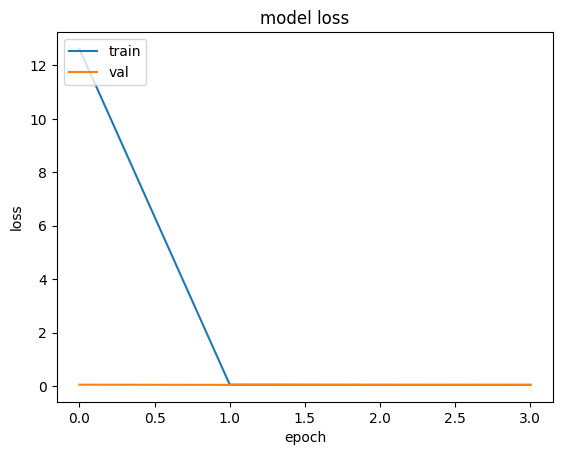

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [19]:
predicted_y = model_conv_keras.predict(x_test)
predicted_y = scaler.inverse_transform(predicted_y)
model_conv_keras.evaluate(x_test, y_test)
y_test = scaler.inverse_transform(y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0464


In [20]:
import numpy as np

def r_squared(y_true, y_pred):

    y_true_mean = np.mean(y_true)

    rss = np.sum(np.square(y_true - y_pred))

    tss = np.sum(np.square(y_true - y_true_mean))

    r_squared = 1 - (rss / tss)

    return r_squared

r_squared_value = r_squared(y_test, predicted_y)
print("R-squared value:", r_squared_value)


R-squared value: 0.9239733625758122


Best Predictions:


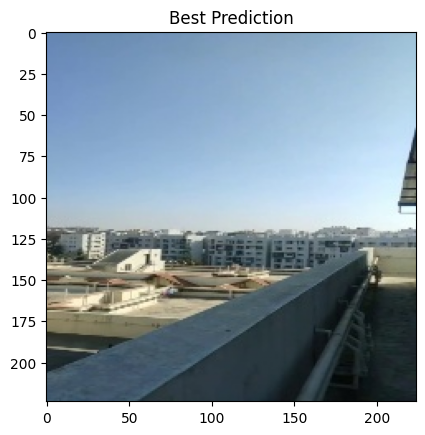

Predicted Values: [ 52.5861    26.616938  45.275467  17.704473 217.46964    7.130026
  14.424321]
Actual Values: [ 47.  24.  46.  19. 216.   8.  14.]




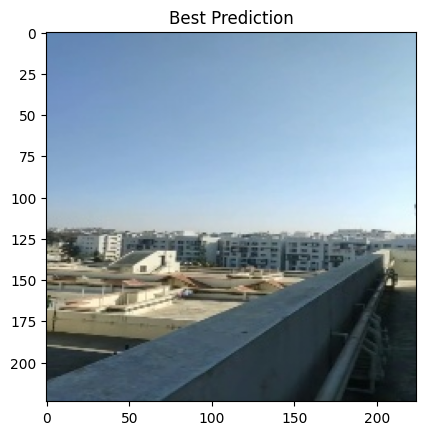

Predicted Values: [ 52.761402   26.869598   46.323982   17.921926  217.92361     7.2451816
  14.425404 ]
Actual Values: [ 47.  24.  46.  19. 216.   8.  14.]




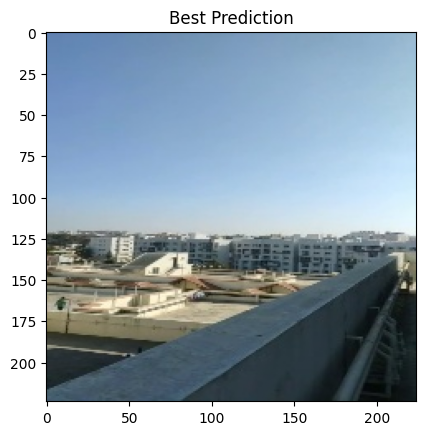

Predicted Values: [ 53.280354   27.42826    47.75099    18.277348  217.5546      7.4809895
  14.310657 ]
Actual Values: [ 47.  24.  46.  19. 216.   8.  14.]


Worst Predictions:


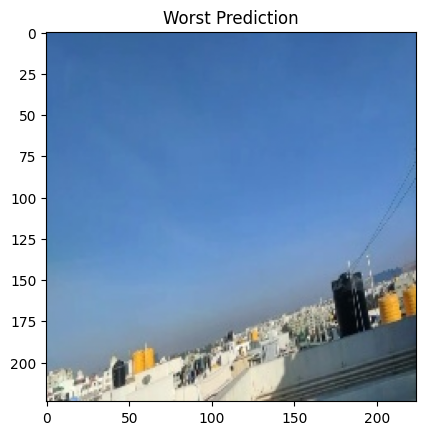

Predicted Values: [ 62.67847    32.726112   57.797783   19.654171  211.46039     6.5142913
  15.975173 ]
Actual Values: [136.  76. 137.  55. 228.   3.  23.]




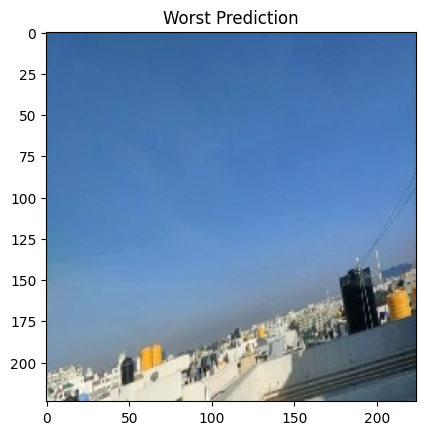

Predicted Values: [ 62.618095   32.672997   57.830482   19.749556  211.10475     6.4943414
  15.762121 ]
Actual Values: [136.  76. 137.  55. 228.   3.  23.]




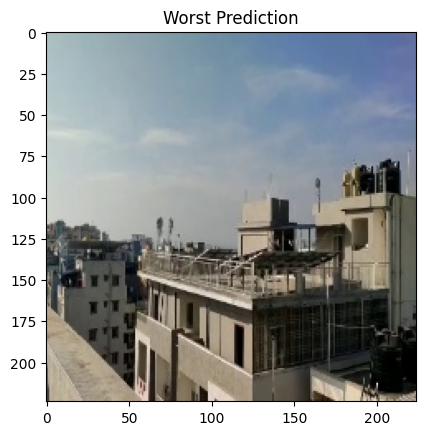

Predicted Values: [ 58.428738   24.127264   44.22161    20.708923  240.70311     7.4747596
  15.515652 ]
Actual Values: [111.  54. 111.  39. 319.   7.  29.]




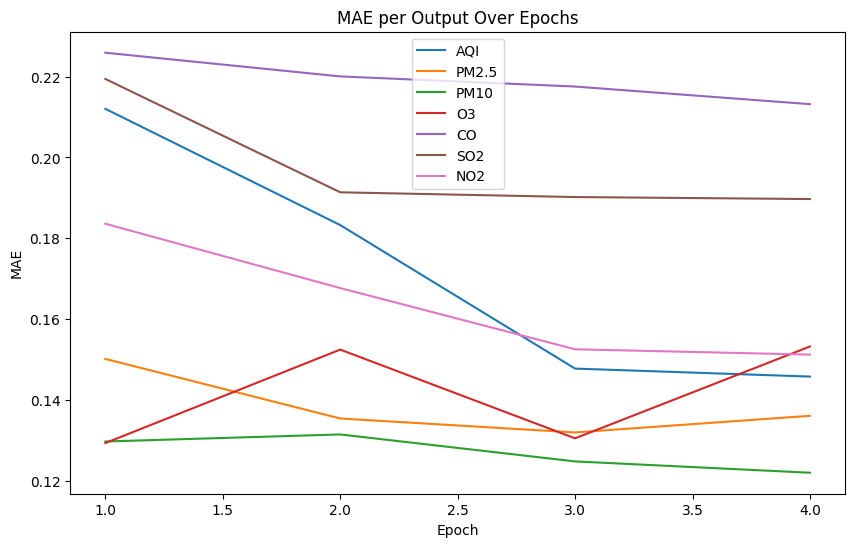

In [21]:
absolute_errors = np.abs(y_test - predicted_y)
mae_per_example = np.mean(absolute_errors, axis=1)

best_indices = np.argsort(mae_per_example)[:3]
worst_indices = np.argsort(mae_per_example)[-3:]

print("Best Predictions:")
for idx in best_indices:
    # Assuming X_test contains the images
    img = x_test[idx]
    plt.imshow(img)
    plt.title("Best Prediction")
    plt.show()
    print("Predicted Values:", predicted_y[idx])
    print("Actual Values:", y_test[idx])
    print("\n")

print("Worst Predictions:")
for idx in worst_indices:
    # Assuming X_test contains the images
    img = x_test[idx]
    plt.imshow(img)
    plt.title("Worst Prediction")
    plt.show()

    print("Predicted Values:", predicted_y[idx])
    print("Actual Values:", y_test[idx])
    print("\n")
    mae_per_output = np.array(mae_callback.mae_per_output)

plt.figure(figsize=(10, 6))
for i in range(mae_per_output.shape[1]):
    label = output_labels.get(i, f'MAE Output {i + 1}')
    plt.plot(range(1, len(mae_per_output) + 1), mae_per_output[:, i], label=label)

plt.title('MAE per Output Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [22]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
import cv2
import matplotlib.pyplot as plt
def resize_image_numpy(image_path, target_width, target_height):
    """Resize the image using NumPy."""
    # Open the image using Pillow (PIL)
    image = cv2.imread(image_path) #Image.open(image_path)

    # Resize the image
    resized_image = cv2.resize(image, (target_width, target_height), interpolation = cv2.INTER_AREA) #resample=Image.LANCZOS)

    # Convert the resized image to a NumPy array
    resized_image_array = np.array(resized_image)

    return resized_image_array

In [23]:
class ImageUploaderApp:
    def __init__(self, master):
        self.master = master
        self.master.title("Air Quality Predictor")
        self.master.minsize(width=800, height=500)

        # Color Scheme
        self.master.configure(bg='#FFB6C1')  # Light gray background

        # Fonts
        self.title_font = ("Helvetica", 16, "bold")
        self.label_font = ("Arial", 12)

        # Image Label
        self.image_label = tk.Label(self.master, text="Uploaded Image will be displayed here",
                                    font=self.label_font, bg="#ffffff", pady=10)
        self.image_label.pack()

        # Upload Button
        self.upload_button = tk.Button(self.master, text="Upload Image", command=self.upload_image,
                                       font=self.label_font, bg="#4CAF50", fg="#ffffff")  # Green button
        self.upload_button.pack(pady=10)

        # Save Button
        self.save_button = tk.Button(self.master, text="Save Image", command=self.save_image,
                                     font=self.label_font, bg="#008CBA", fg="#ffffff")  # Blue button
        self.save_button.pack(pady=10)

        self.image_path = None

    def upload_image(self):
        file_path = filedialog.askopenfilename(title="Select an Image File",
                                               filetypes=[("Image files", "*.png;*.jpg;*.jpeg;*.gif")])

        if file_path:
            self.image_path = file_path

            # Display the uploaded image
            #root = tkinter.Tk()
            image = Image.open(file_path)
            #original_image = Image.open(file_path)
            resized_image = image.resize((224, 224), Image.Resampling.LANCZOS)#ANTIALIAS)

        # Display the resized image on the tkinter window
        #image = ImageTk.PhotoImage(resized_image)
        #image_label.config(image=image)
        #image_label.image = image  # keep a reference to avoid garbage collection
            #target_width = 224
            #target_height = 224
            #resized_image = resize_image_numpy(file_path, target_width, target_height)
            #image = tf.image.decode_jpeg(image, channels=3)
            #target_height = 224
            #target_width = 224
            #resized_image = tf.image.resize(image, [target_height, target_width])

            # If you need to scale pixel values between 0 and 1
            #resized_image = resized_image / 255.0
            #image = resized_image

            image = ImageTk.PhotoImage(resized_image)
            self.image_label.config(image=image)
            self.image_label.image = image

    def save_image(self):
        if self.image_path:
            save_path = filedialog.asksaveasfilename(defaultextension=".png",
                                                     filetypes=[("PNG files", "*.png"), ("All files", "*.*")])
            if save_path:
                # Copy the image to the desired location
                image = Image.open(self.image_path)
                image.save(save_path)
                tk.messagebox.showinfo("Image Saved", f"The image has been saved to {save_path}")

                # im = cv2.imread(image, mode='RGB')
                im = imread(save_path)
                print(type(im))
                print(im.shape)

                #image_path = 'path_to_your_image.jpg'
                #image = tf.io.read_file(image_path)
                #im = tf.image.decode_jpeg(image, channels=3)  # Assuming RGB image

                # Resize the image
                target_height = 224
                target_width = 224
                resized_image = resize_image_numpy(save_path, target_width, target_height)
                #resized_image = tf.image.resize(image, [target_height, target_width])

                # If you need to scale pixel values between 0 and 1
                #resized_image = resized_image / 255.0

                # Convert the image to a format suitable for the model input
                #resized_image = tf.expand_dims(resized_image, axis=0)  # Add batch dimension
                im = resized_image

                im = np.expand_dims(im, axis=0)
                print(im.shape)
                output = model_conv_keras.predict(im)
                type(output)
                output = scaler.inverse_transform(output)

                my_output = tk.Label(text="The AQI level is Moderate" +
                                          "\nThe PM2.5 level is " + str(output[0, 1]) +
                                          "\nThe PM10 level is " + str(output[0, 2]) +
                                          "\nThe O3 level is " + str(output[0, 3]) +
                                          "\nThe CO level is " + str(output[0, 4]) +
                                          "\nThe SO2 level is " + str(output[0, 5]) +
                                          "\nThe NO2 level is " + str(output[0, 6]), font=("Helvetica", 16,"bold"))
                my_output.pack()



            else:
                tk.messagebox.showwarning("Warning", "Please choose a valid save location.")
        else:
            tk.messagebox.showwarning("Warning", "Please upload an image first.")


if __name__ == "__main__":
    root = tk.Tk()
    app = ImageUploaderApp(root)
    root.mainloop()

<class 'numpy.ndarray'>
(224, 224, 3)
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
